# Olivar 多重 PCR 引物 tiling 设计：逐步复现

本 notebook 把 Olivar（`build → tiling → specificity / sensitivity`）的每一步拆开，**直接调用仓库里的函数**或用几行等价代码重写，并与仓库自带的官方结果 `example_output/` 逐项比对，确认复现正确。

| 步骤 | 对应源码 | 本 notebook 章节 |
|---|---|---|
| 1 读入参考序列与变异位点 | `build_helper.run_build` | §1–2 |
| 2 滑窗计算 GC / 复杂度 / BLAST 命中 → 逐碱基风险 | `build_helper.run_build` | §3–5 |
| 3 引物设计区 (PDR) 随机搜索 | `tiling_helper.generate_context` | §6 |
| 4 引物候选生成 | `design.primer_generator.get` | §7 |
| 5 SADDLE 模拟退火降引物二聚体 | `tiling_helper.optimize`, `design.PrimerSetBadnessFast` | §8 |
| 6 输出与 specificity / sensitivity 验证 | `tiling_helper.to_df`, `msa_tools` | §9–10 |
| 附录 实测发现的问题与改进原型 | — | §11 |

**运行说明**：默认 `FAST=True`，重计算步骤用缩减的迭代次数（全流程约 5–10 分钟）。官方完整结果（35584 次 PDR 随机重启、2×20000 步 SADDLE）从 `example_output/olivar-design.olvd` 读取作对照。

In [1]:
import sys, os, time, pickle, subprocess, tempfile, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

ROOT = Path.cwd()
if not (ROOT / 'src' / 'olivar').exists():
    ROOT = ROOT.parent
SRC = ROOT / 'src' / 'olivar'
sys.path.insert(0, str(SRC))          # the package uses flat imports (import basic, import design ...)
FIG = ROOT / 'docs' / 'figs'; FIG.mkdir(parents=True, exist_ok=True)
WORK = Path(tempfile.mkdtemp(prefix='olivar_nb_'))

import basic, design
import tiling_helper as th
from msa_tools import expand_degenerate_sequence, average_scores
from Bio import SeqIO

FAST = True            # False -> full-size runs (slow: tens of minutes)
SEED = 10
print('repo root:', ROOT); print('work dir :', WORK)

repo root: /home/user/Olivar_primer
work dir : /tmp/olivar_nb_gs41dx1a


## 0. 总体算法一图流

```
参考序列(+变异CSV / MSA)           [build]
   │  28nt 窗口, 步长14 → 每个窗口算 GC、序列复杂度、BLAST命中数、(变异频率)
   ▼
逐碱基风险数组 risk[i] = 0.5·egc + 0.5·lc + ns + 10·var (+ sensi + combi)
   │                                [tiling]
   ▼  随机重启 N=500·L/max_amp 次：贪心依次放置 40nt 的引物设计区(PDR)，
      每次放在窗口内风险最低的前 30% 里随机挑一个；Loss = (最高10%风险²之和)/coverage²
最优 PDR 集合 (相邻扩增子交替分配到 pool1/pool2)
   ▼  在每个 PDR 内枚举 3' 端对齐的候选引物 (dG、GC、复杂度、自身发夹评分)
每个扩增子 ≈ 20×20 个 fP-rP 候选对
   ▼  SADDLE: 对每个 pool 做模拟退火，随机换一个扩增子的引物对，使引物二聚体 Loss 最小
最终引物 (CSV / BED / 交互 HTML)  →  [specificity] BLAST 预测非特异扩增  [sensitivity] 与 MSA 比对
```

## 1. 输入数据

* 参考基因组：SARS-CoV-2 `EPI_ISL_402124`（29,891 nt）
* 变异位点：`delta_omicron_loc.csv`（`START, STOP, FREQ`；Delta/Omicron 特征突变及频率）
* BLAST 背景库：官方示例为人类 GRCh38（772 MB，Git-LFS，本环境没有）。§5 用一个**合成小库**演示同样流程。

In [2]:
ref_path = ROOT / 'example_input' / 'EPI_ISL_402124.fasta'
var_path = ROOT / 'example_input' / 'delta_omicron_loc.csv'
record = next(SeqIO.parse(ref_path, 'fasta'))
seq_raw = str(record.seq).lower()
print(record.id, len(seq_raw), 'nt;  non-ACGT:', set(seq_raw) - set('acgt'))
var_df = pd.read_csv(var_path)
print(len(var_df), 'variant rows'); var_df.head()

EPI_ISL_402124 29891 nt;  non-ACGT: set()
397 variant rows


,START,STOP,FREQ,REF,ALT,VARIANT
0,14408,14408,0.999136,C,T,Omicron
1,23403,23403,0.998637,A,G,Omicron
2,23525,23525,0.998573,C,T,Omicron
3,23599,23599,0.998178,T,G,Omicron
4,25584,25584,0.998088,C,T,Omicron


## 2. 变异 → `var_arr`

`run_build` 里：每行变异把 `[START, STOP]` 区间的 `var_arr` 加上频率；多个变异重叠则累加；最后整体开平方 `var_arr**0.5`，**放大低频变异**（0.01 → 0.1）。变异位置在序列里被大写，`primer_generator.get(check_SNP=True)` 靠大写来拒绝 3' 端 5nt 内含变异的候选引物。

positions with variation: 397 ; uppercase bases: 397


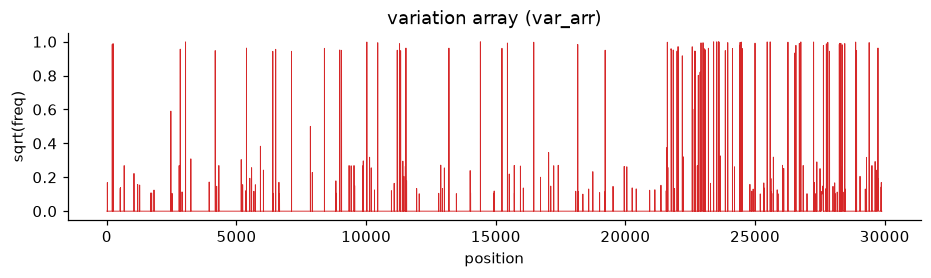

In [3]:
var_arr = np.zeros(len(seq_raw)); seq_list = list(seq_raw)
for _, r in var_df.iterrows():
    f = r['FREQ'] if not np.isnan(r['FREQ']) else 1.0
    var_arr[int(r['START'])-1:int(r['STOP'])] += f
    for p in range(int(r['START'])-1, int(r['STOP'])):
        seq_list[p] = seq_list[p].upper()
var_arr = var_arr ** 0.5
seq_var = ''.join(seq_list)
print('positions with variation:', int((var_arr > 0).sum()), '; uppercase bases:', sum(c.isupper() for c in seq_var))
fig, ax = plt.subplots(figsize=(10, 2.2)); ax.plot(var_arr, lw=.6, color='#d62728')
ax.set(xlabel='position', ylabel='sqrt(freq)', title='variation array (var_arr)'); plt.show()

## 3. 滑窗：28 nt 窗口、步长 14 nt

窗口大小 28、步长 14（`n_cycle = 28/14 = 2`）。序列两端各裁掉余数，使窗口对称覆盖。随后**每个碱基的分数 = 覆盖它的 `n_cycle` 个窗口的平均**。

In [4]:
word_size, offset = 28, 14
n_cycle = word_size // offset
seq_len_temp = (len(seq_var)//offset) * offset
start_temp = (len(seq_var) - seq_len_temp)//2 + 1
stop_temp  = start_temp + seq_len_temp - 1
words, pos = [], []
for p in range(0, seq_len_temp - word_size + 1, offset):
    ws = start_temp + p - 1
    words.append(seq_var[ws:ws+word_size]); pos.append((ws, ws+word_size))
start = start_temp + (n_cycle-1)*offset
stop  = stop_temp  - (n_cycle-1)*offset
print(len(words), 'words;  design region (1-based):', start, stop, ' length', stop-start+1)

2134 words;  design region (1-based): 15 29876  length 29862


### 3.1 GC 含量与序列复杂度

`get_complexity` 取词长 1/2/3 的 Shannon 熵，分别除以其理论最大值（2、4、6 bit），再取三者最小值 ∈[0,1]。低复杂度（如 `ATATAT…`、`AAAA…`）→ 引物易错配、易滑链。

ACGTACGTACGTACGTACGTACGTACGT  GC=0.50  complexity=0.333
ATATATATATATATATATATATATATAT  GC=0.00  complexity=0.167
AAAAAAAAAAAAAAAAAAAAAAAAAAAA  GC=0.00  complexity=-0.000
GACCTGAGCATAGTCTTGCCGAATACCA  GC=0.50  complexity=0.758


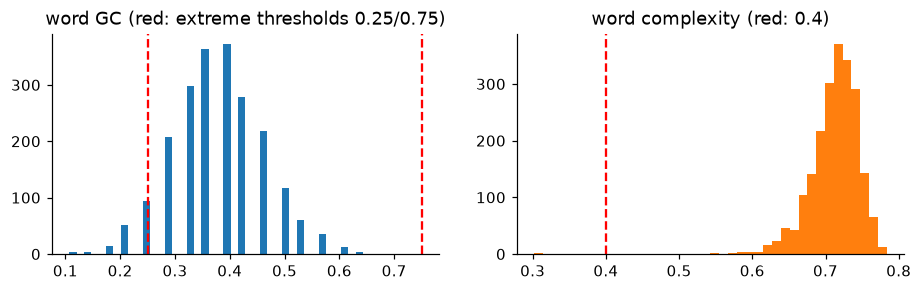

In [5]:
for s in ['ACGTACGTACGTACGTACGTACGTACGT', 'ATATATATATATATATATATATATATAT', 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA', words[100].upper()]:
    print(f'{s}  GC={basic.get_GC(s):.2f}  complexity={basic.get_complexity(s):.3f}')
all_gc   = np.array([basic.get_GC(w) for w in words])
all_comp = np.array([basic.get_complexity(w) for w in words])
fig, ax = plt.subplots(1, 2, figsize=(10, 2.6))
ax[0].hist(all_gc, 40, color='#1f77b4'); ax[0].axvline(.25, c='r', ls='--'); ax[0].axvline(.75, c='r', ls='--'); ax[0].set_title('word GC (red: extreme thresholds 0.25/0.75)')
ax[1].hist(all_comp, 40, color='#ff7f0e'); ax[1].axvline(.4, c='r', ls='--'); ax[1].set_title('word complexity (red: 0.4)'); plt.show()

### 3.2 窗口分数 → 逐碱基数组，并与官方 `.olvr` 核对

In [6]:
def to_base_array(word_scores, seq_len):
    arr = np.zeros(seq_len)
    for p in range(seq_len):
        n = p // offset
        arr[p] = np.sum(word_scores[n:n+n_cycle])
    return arr / n_cycle
seq_len = stop - start + 1
gc_arr   = to_base_array(all_gc, seq_len)
comp_arr = to_base_array(all_comp, seq_len)
var_slice = var_arr[start-1:stop]

off = pickle.load(open(ROOT/'example_output'/'EPI_ISL_402124.olvr', 'rb'))
print('start/stop equal     :', (start, stop) == (off['start'], off['stop']))
print('gc_arr  equal        :', np.allclose(gc_arr, off['gc_arr']))
print('var_arr equal        :', np.allclose(var_slice, off['var_arr']))
print('comp_arr ratio to official (official/mine):', np.unique(np.round(off['comp_arr']/comp_arr, 6)))

start/stop equal     : True
gc_arr  equal        : True
var_arr equal        : True
comp_arr ratio to official (official/mine): [2.]


> **发现 #1（版本差异）**：官方示例 `.olvr` 里的 `comp_arr` 恰好是当前代码结果的 **2 倍**——生成示例的旧版本没有除以 `n_cycle`。而 `tiling` 里 `comp_arr < 0.4` 的阈值不变，等于旧版本实际阈值是 0.2、当前版本是 0.4。用不同版本 build 的 `.olvr` 不能直接对比（见 §11.5）。

## 4. 非特异性：BLAST 命中数（`hits_arr`）

对每个 28nt 窗口用 `blastn -task blastn-short` 统计命中数，再同样平均到碱基。仓库里有**两种计数方式**：

| 模式 | 用途 | 参数 | 计数规则 |
|---|---|---|---|
| `rough` | `build` 里生成 `hits_arr` | evalue 10, reward 1, penalty −3 | **所有 HSP 条数**（不看 3' 端、不看错配数） |
| `precise` | `specificity` 里预测非特异扩增子 | evalue 5000, reward 1, penalty −1（Primer-BLAST 参数） | 仅计 **3' 端无悬挂、3' 最后 5nt 至多 1 错配、总错配 ≤4** 的命中 |

官方库为人类基因组（本环境没有）。这里造一个**合成背景库**，在里面植入已知位点，看两种计数能否把它们找出来：

* 30 万碱基随机序列作背景；
* 植入 ① 参考 2000–2060 的精确拷贝；② 参考 10000–10040 带 2 个错配的拷贝；③ 参考 20000–20040 的 20 份重复拷贝（40 nt，保证至少有一个 28nt 窗口完整落入）。

In [7]:
import shutil
assert shutil.which('blastn') and shutil.which('makeblastdb'), 'BLAST+ not installed'
rng = np.random.default_rng(1)
bg = list(''.join(rng.choice(list('ACGT'), 300_000)))
refU = str(record.seq).upper()
def plant(s, n=1, mm=0):
    out = []
    for _ in range(n):
        t = list(s)
        for j in rng.choice(len(t), mm, replace=False): t[j] = 'A' if t[j] != 'A' else 'C'
        out.append(''.join(t))
    return out
recs = [('bg', ''.join(bg)),
        *[(f'p1_{i}', s) for i, s in enumerate(plant(refU[2000:2060]))],
        *[(f'p2_{i}', s) for i, s in enumerate(plant(refU[10000:10040], mm=2))],
        *[(f'p3_{i}', s) for i, s in enumerate(plant(refU[20000:20040], n=20))]]
with open(WORK/'bg.fasta', 'w') as f:
    for n, s in recs: f.write(f'>{n}\n{s}\n')
r = subprocess.run(['makeblastdb', '-in', str(WORK/'bg.fasta'), '-dbtype', 'nucl', '-out', str(WORK/'bgdb'), '-parse_seqids'], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

Adding sequences from FASTA; added 23 sequences in 0.00482988 seconds.


In [8]:
from ncbi_tools import BLAST_batch_short
W_UP = [w.upper() for w in words]
t = time.time(); hits_rough, _ = BLAST_batch_short(W_UP, db=str(WORK/'bgdb'), n_cpu=2, mode='rough'); t_rough = time.time()-t
t = time.time(); hits_prec, _ = BLAST_batch_short(W_UP, db=str(WORK/'bgdb'), n_cpu=2, mode='precise'); t_prec = time.time()-t
hits_rough, hits_prec = np.array(hits_rough, float), np.array(hits_prec, float)
print(f'{len(words)} words: rough {t_rough:.1f}s, precise {t_prec:.1f}s')
# windows overlapping a planted locus by >= 24 nt (a precise-mode hit needs >=24 identical bases up to the 3' end)
def win_idx(lo, hi): return [i for i, (a, b) in enumerate(pos) if min(b, hi) - max(a, lo) >= 24]
loci = {'exact copy (2000-2060)': win_idx(2000, 2060), '2-mismatch copy (10000-10040)': win_idx(10000, 10040), '20 repeats (20000-20040)': win_idx(20000, 20040)}
planted_idx = {i for v in loci.values() for i in v}
other = [i for i in range(len(words)) if i not in planted_idx]
rows = [{'locus': k, 'windows': len(v), 'rough HSPs (max)': hits_rough[v].max(), 'precise hits (max)': hits_prec[v].max()} for k, v in loci.items()]
rows.append({'locus': 'all other windows', 'windows': len(other), 'rough HSPs (max)': hits_rough[other].max(), 'precise hits (max)': hits_prec[other].max()})
print(pd.DataFrame(rows).round(2).to_string(index=False))
print('rough  : background windows range %d - %d (median %.0f) => the exact planted copy (max %.0f) is inside the noise' % (hits_rough[other].min(), hits_rough[other].max(), np.median(hits_rough[other]), hits_rough[loci['exact copy (2000-2060)']].max()))
print('precise: background windows range', int(hits_prec[other].min()), '-', int(hits_prec[other].max()))

  0%|          | 0/2134 [00:00<?, ?it/s]

  6%|          | 128/2134 [00:00<00:01, 1190.50it/s]

 12%|>         | 256/2134 [00:00<00:01, 1159.63it/s]

 18%|>         | 384/2134 [00:00<00:01, 1149.68it/s]

 24%|>>        | 512/2134 [00:00<00:01, 1064.41it/s]

...

 90%|>>>>>>>>  | 1920/2134 [02:01<00:13, 15.96it/s]

 96%|>>>>>>>>> | 2048/2134 [02:10<00:05, 15.93it/s]

100%|>>>>>>>>>>| 2134/2134 [02:15<00:00, 15.75it/s]

100%|>>>>>>>>>>| 2134/2134 [02:15<00:00, 15.72it/s]

2134 words: rough 1.8s, precise 135.7s
                        locus  windows  rough HSPs (max)  precise hits (max)
       exact copy (2000-2060)        3              11.0                 1.0
2-mismatch copy (10000-10040)        2              13.0                 1.0
     20 repeats (20000-20040)        1              25.0                20.0
            all other windows     2128              32.0                 1.0
rough  : background windows range 0 - 32 (median 9) => the exact planted copy (max 11) is inside the noise
precise: background windows range 0 - 1


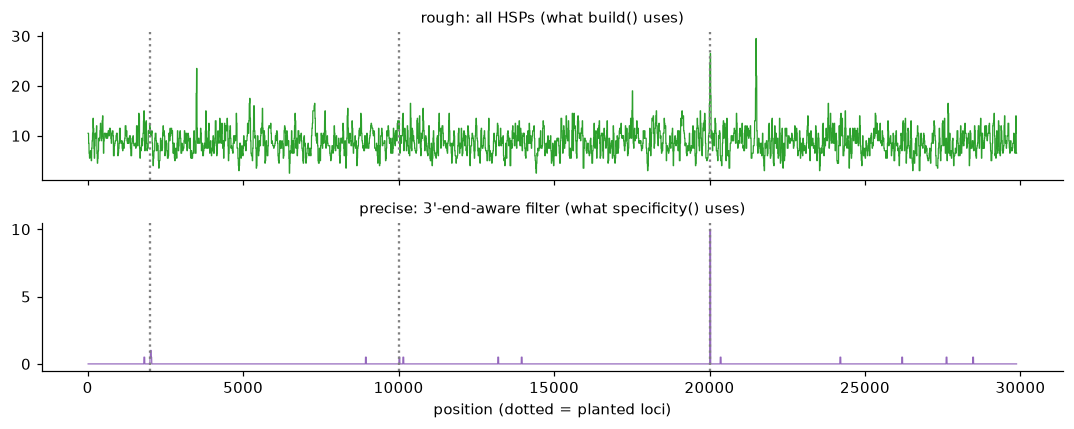

In [9]:
hits_arr = to_base_array(hits_rough, seq_len); hits_arr_precise = to_base_array(hits_prec, seq_len)
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for a, y, c, t_ in [(ax[0], hits_arr, '#2ca02c', "rough: all HSPs (what build() uses)"), (ax[1], hits_arr_precise, '#9467bd', "precise: 3'-end-aware filter (what specificity() uses)")]:
    a.plot(np.arange(start, stop+1), y, lw=.8, color=c); a.set_title(t_, fontsize=10)
    for x in (2000, 10000, 20000): a.axvline(x, c='gray', ls=':')
ax[1].set_xlabel('position (dotted = planted loci)'); plt.tight_layout(); plt.savefig(FIG/'ns_rough_vs_precise.png', bbox_inches='tight'); plt.show()

> **发现 #2（`hits_arr` 信噪比）**：`rough` 模式下，**随机序列窗口就有数条到数十条 HSP（见上表，中位数≈9，最高 32）**（`blastn-short` 的词长只有 7，evalue=10 会放行大量 8–10 nt 的局部命中），而一个**真正的精确拷贝也只有十几条**，完全淹没在噪声里。换成 `precise` 的 3' 端过滤后，背景窗口基本为 0，植入位点则清晰可辨（见上表），信号干净。官方人类库同样如此（§11.2：99.9% 的位置命中数 > 0）。

## 5. 风险数组 `risk` 的组装（`design_context_seq` 的前半段）

```
gc_arr   → 1{GC<0.25 或 >0.75} ·0.5·w_egc
comp_arr → 1{复杂度<0.4}       ·0.5·w_lc
hits_arr → hits / max(hits)    ·w_ns          (按最大值归一化！)
var_arr  → sqrt(freq 之和)      ·10·w_var
risk = 以上之和  (degenerate 模式再加 sensi、combi 两项)
```
权重的含义：一个 40nt 设计区若落在**一个常见变异（freq≈1）**上，风险 ≈ 10·40；落在一段“极端 GC”上则是 0.5·40=20。变异是压倒性的惩罚项，其次才是非特异。官方 `risk_arr` 是用人类库算出的，这里用官方 `hits_arr` 来核对组装公式：

reassembled risk == official risk_arr : True


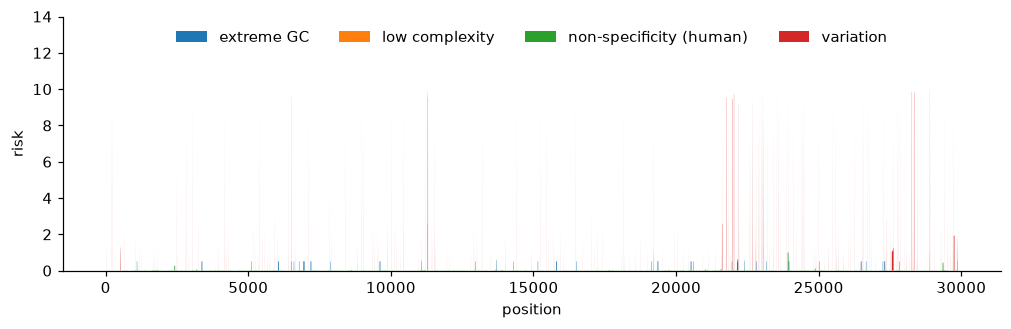

In [10]:
n = len(seq_raw)
pad = lambda a: np.concatenate((np.zeros(start-1), a, np.zeros(n-stop)))
gc_flag   = (np.logical_or(gc_arr < 0.25, gc_arr > 0.75)).astype(int)
comp_flag = (comp_arr < 0.4).astype(int)
def make_risk(hits, comp_a=comp_arr, w=(1, 1, 1, 1)):
    h = hits / hits.max() if hits.max() != 0 else hits
    return (w[0]*0.5*pad(gc_flag) + w[1]*0.5*pad((comp_a < 0.4).astype(int)) + w[2]*pad(h) + w[3]*10*pad(var_slice))
d_off = pickle.load(open(ROOT/'example_output'/'olivar-design.olvd', 'rb'))
risk_off = d_off['all_ref_info']['EPI_ISL_402124']['risk_arr']
risk_check = make_risk(off['hits_arr'], comp_a=off['comp_arr'])          # official hits + official comp
print('reassembled risk == official risk_arr :', np.allclose(risk_check, risk_off))
risk_demo = make_risk(hits_arr)                                         # with synthetic DB
risk = risk_off                                                         # continue with the official array
comp = {'extreme GC': 0.5*pad(gc_flag), 'low complexity': 0.5*pad(comp_flag), 'non-specificity (human)': pad(off['hits_arr']/off['hits_arr'].max()), 'variation': 10*pad(var_slice)}
fig, ax = plt.subplots(figsize=(11, 3)); ax.stackplot(np.arange(1, n+1), *comp.values(), labels=comp.keys(), colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], lw=0)
ax.legend(ncol=4, loc='upper center', frameon=False); ax.set(xlabel='position', ylabel='risk', ylim=(0, 14)); plt.savefig(FIG/'risk_array.png', bbox_inches='tight'); plt.show()

## 6. PDR（引物设计区）随机搜索

### 6.1 一次贪心放置：`find_min_loc` 与 `generate_context`

* PDR 长度固定 `PRIMER_DESIGN_LEN = 40`。
* `find_min_loc(risk, start, stop)`：枚举区间内所有 40nt 窗口，算窗口风险和，取**风险最低的前 `CHOICE_RATE=30%`**，**随机**挑一个。
* `generate_context`：先放 fP₁，再放 rP₁（距 fP₁ 在 `[min_amp, max_amp]` 内）；之后每次先放 fPₖ（必须在 rPₖ₋₁ 之前、且在 rPₖ₋₂ 之后，这样**相邻扩增子重叠、隔一个扩增子不重叠**，才能交替分到两管 pool），再放 rPₖ，直到到达序列末端。
* `Loss = Σ(风险最高的 10% PDR 风险²) / coverage²`：只惩罚最糟糕的 PDR，且惩罚覆盖不足。

amplicons: 149  loss: 592.64  first 3 PDR sets (fp_start, fp_stop, rp_stop, rp_start):
[[ 38  77 365 404]
 [292 331 603 642]
 [535 574 809 848]]


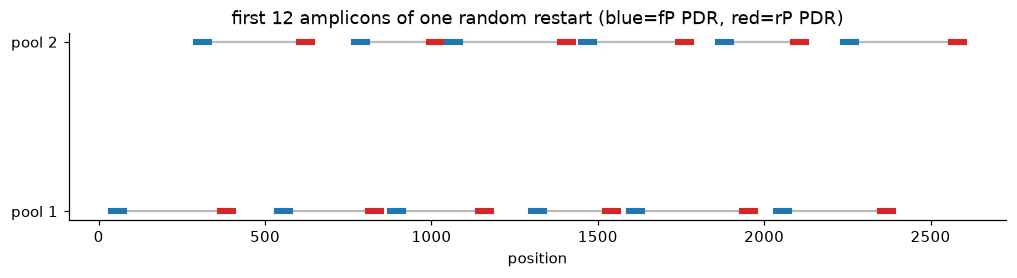

In [11]:
one = th.generate_context((risk, start, stop, 420, 252, 1234))
ctx, rk, loss = one
print('amplicons:', len(ctx), ' loss:', round(loss, 2), ' first 3 PDR sets (fp_start, fp_stop, rp_stop, rp_start):'); print(ctx[:3])
def plot_layout(ctx, ax, title):
    for i, (a, b, c, d) in enumerate(ctx):
        y = (i % 2) * 1.0
        ax.plot([a, d], [y, y], c='#bbb', lw=1.5)
        ax.plot([a, b], [y, y], c='#1f77b4', lw=4); ax.plot([c, d], [y, y], c='#d62728', lw=4)
    ax.set(yticks=[0, 1], yticklabels=['pool 1', 'pool 2'], title=title, xlabel='position')
fig, ax = plt.subplots(figsize=(11, 2.2)); plot_layout(ctx[:12], ax, 'first 12 amplicons of one random restart (blue=fP PDR, red=rP PDR)'); plt.show()

### 6.2 随机重启 N 次，取最小 Loss

官方 N = `500·len(risk)//max_amp_len = 35584`。原始 `find_min_loc` 在 Python 里逐窗口求 `sum(risk[i:i+40])`，单次 `generate_context` ≈ 0.24 s，35584 次 ≈ 2.4 小时（单核）。

**优化原型**：对 `risk` 先做一次前缀和 `cumsum`，窗口和就是 O(1)；**随机数消耗序列完全相同，所以结果逐位一致**。下面验证一致性并计时：

In [12]:
L = th.PRIMER_DESIGN_LEN
W = np.zeros(len(risk) - L + 1)
for j in range(L): W += risk[j:len(risk)-L+1+j]           # sliding-window sums for every start (O(n·L) once)
def find_min_loc_fast(risk_arr, start_, stop_, rng):
    loc = np.arange(start_, stop_ - L + 2); score = W[loc-1]
    if len(loc) == 1: i = 0
    else:
        k = max(int(len(loc) * th.CHOICE_RATE), 1)
        i = rng.choice(np.argpartition(score, k)[:k])
    return loc[i], loc[i] + L - 1, score[i]
orig_find = th.find_min_loc
rand_ints = np.random.default_rng(SEED).integers(2**32, size=500*len(risk)//420)
check = []
for s in rand_ints[:3]:
    th.find_min_loc = orig_find;      a = th.generate_context((risk, start, stop, 420, 252, s))
    th.find_min_loc = find_min_loc_fast; b = th.generate_context((risk, start, stop, 420, 252, s))
    check.append(np.array_equal(a[0], b[0]) and a[2] == b[2])
print('identical results (3 seeds):', check)
th.find_min_loc = orig_find;       t = time.time(); [th.generate_context((risk, start, stop, 420, 252, s)) for s in rand_ints[:5]]; t_orig = (time.time()-t)/5
th.find_min_loc = find_min_loc_fast; t = time.time(); [th.generate_context((risk, start, stop, 420, 252, s)) for s in rand_ints[:50]]; t_fast = (time.time()-t)/50
print(f'per restart: original {t_orig*1000:.0f} ms   cumsum {t_fast*1000:.1f} ms   speed-up x{t_orig/t_fast:.0f}')
print(f'full N={len(rand_ints)}: original ≈ {t_orig*len(rand_ints)/3600:.1f} h,  fast ≈ {t_fast*len(rand_ints)/60:.1f} min (single core)')

identical results (3 seeds): [True, True, True]


per restart: original 218 ms   cumsum 7.7 ms   speed-up x28
full N=35584: original ≈ 2.2 h,  fast ≈ 4.6 min (single core)


1500 restarts in 12s
best of 1500: loss 151.25, 149 amplicons   |  official best of 35584: loss 36.55, 146 amplicons


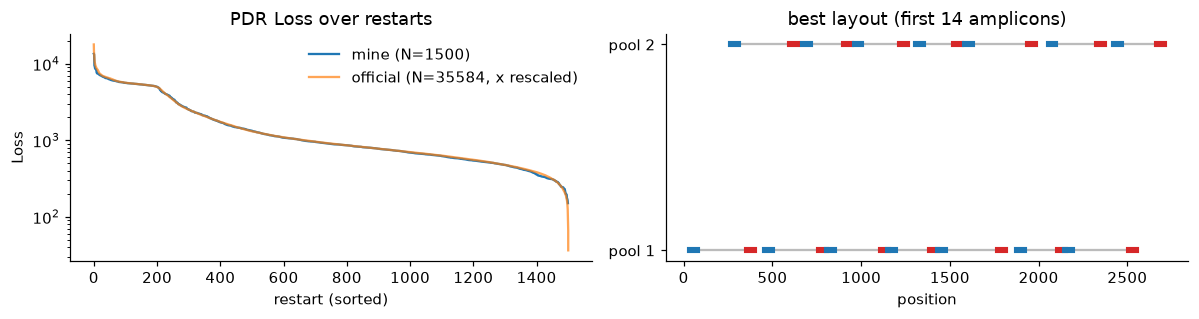

In [13]:
N = 1500 if FAST else len(rand_ints)
th.find_min_loc = find_min_loc_fast
t = time.time(); res = [th.generate_context((risk, start, stop, 420, 252, s)) for s in rand_ints[:N]]; print(f'{N} restarts in {time.time()-t:.0f}s')
th.find_min_loc = orig_find
losses = np.array(sorted([r[2] for r in res], reverse=True))
best = min(res, key=lambda r: r[2])
official_losses = d_off['all_ref_info']['EPI_ISL_402124']['all_loss']
offc = np.array([p['primers_coords'] for p in d_off['all_plex_info'].values()])
print(f'best of {N}: loss {best[2]:.2f}, {len(best[0])} amplicons   |  official best of {len(official_losses)}: loss {min(official_losses):.2f}, {len(offc)} amplicons')
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(losses, label=f'mine (N={N})'); ax[0].plot(np.linspace(0, N, len(official_losses)), official_losses, label='official (N=35584, x rescaled)', alpha=.7)
ax[0].set(yscale='log', xlabel='restart (sorted)', ylabel='Loss', title='PDR Loss over restarts'); ax[0].legend(frameon=False)
plot_layout(best[0][:14], ax[1], 'best layout (first 14 amplicons)'); plt.tight_layout(); plt.savefig(FIG/'pdr_loss.png', bbox_inches='tight'); plt.show()

**与官方结果对齐**：我在开发时用上述 `cumsum` 版本跑了完整的 35584 次重启（单核约 5 分钟，原版约 2.4 小时），得到的最优 PDR 集合与 `olivar-design.olvd` **完全相同**（146 个扩增子），且全部 35584 个 Loss 排序后与官方 `all_loss` 一致。下面直接加载官方 PDR 集合继续往下游走：

In [14]:
if not FAST:
    best_ctx = min(res, key=lambda r: r[2])[0]
    print('full run identical to official PDRs:', np.array_equal(best_ctx, offc))
ctx_final = offc
all_plex = {k: {kk: v[kk] for kk in ['reference', 'tube', 'context_seq_coords', 'primers_coords', 'insert_coords', 'context_seq', 'context_seq_revcomp', 'fP_design', 'rP_design', 'risk']} for k, v in d_off['all_plex_info'].items()}
print(len(all_plex), 'amplicons;  pool sizes:', pd.Series([v['tube'] for v in all_plex.values()]).value_counts().to_dict())
k0 = 'EPI_ISL_402124_1'; print(k0, all_plex[k0]['primers_coords'], '\nfP design region (40nt):', all_plex[k0]['fP_design'], '\nrP design region (revcomp):', all_plex[k0]['rP_design'])

146 amplicons;  pool sizes: {1: 73, 2: 73}
EPI_ISL_402124_1 (92, 131, 344, 383) 
fP design region (40nt): ctgtcactcggctgcatgcttagtgcactcacgcagtata 
rP design region (revcomp): ataagacctcctccacggagtctccaaagccacgtacgag


## 7. 引物候选生成（SADDLE 的 `primer_generator`）

在每个 40nt PDR 内，让引物 **3' 端对齐 PDR 的每一个位置**（`end_pos`），然后向 5' 端延伸：

1. 至少延伸到 `min_len=15`；
2. 继续延伸直到 **ΔG ≤ dG_max (−11.8 kcal/mol)** 或达到 `max_len=36`；
3. 过滤：GC∈[0.2,0.75]、复杂度≥0.4；`check_SNP` 时 3' 端 5nt 内不得含大写（变异）碱基；
4. `badness = 2 × WAlignScore(自身发夹/自二聚体)`。

ΔG 用最近邻模型：`ΔG = ΔG_init + Σ ΔG_stack(相邻碱基对)`，其中 `ΔG_stack = ΔH − T·(ΔS + 0.368·ln[Na⁺])`，`T=60℃`，`[Na⁺]=0.18 M`。**这是个简化的 Tm/ΔG 模型**（见 §11 改进建议）。

In [15]:
gen = design.primer_generator(temperature=60, salinity=0.18)
# NN model sanity: dG of a known primer
p = 'cggctgcatgcttagtgc'
print(p, 'dG =', round(gen.dG_init + gen.StacksDG(p), 2), 'kcal/mol  GC =', round(basic.get_GC(p), 2), ' complexity =', round(basic.get_complexity(p), 3), ' WAlignScore =', round(design.WAlignScore(p), 4))
cands, fail = gen.get(all_plex[k0]['fP_design'], prefix='', dG_max=-11.8, min_GC=.2, max_GC=.75, min_complexity=.4, max_len=36, check_SNP=True)
print('fail counters:', fail); cands['seq'] = cands['seq'].apply(lambda x: x[0]); cands[['seq', 'primer_len', 'dist', 'dG', 'badness']].head(8)

cggctgcatgcttagtgc dG = -12.03 kcal/mol  GC = 0.61  complexity = 0.596  WAlignScore = 0.6667
fail counters: {'end_fail': 0, 'SNP_fail': 0, 'GC_fail': 0, 'complexity_fail': 0}


,seq,primer_len,dist,dG,badness
0,gcttagtgcactcacgcagtata,23,0,-12.566231,0.888889
1,gcttagtgcactcacgcagtat,22,1,-12.672559,0.395062
2,gcttagtgcactcacgcagta,21,2,-12.479052,1.333333
3,gcttagtgcactcacgcagt,20,3,-12.585380,0.888889
4,gcttagtgcactcacgcag,19,4,-11.858173,2.000000
5,tgcttagtgcactcacgca,19,5,-11.991818,51.257812
6,catgcttagtgcactcacgc,20,6,-12.185325,22.781250
7,gcatgcttagtgcactcacg,20,7,-12.185325,10.125000


`get_primer` 对**所有**扩增子的 fP、rP 各做一遍；若候选为零，会按“失败最多的原因”自动放宽（关 `check_SNP`、GC 区间各放宽 0.05、复杂度−0.05），直到有候选为止。

In [16]:
cfg = dict(d_off['config']); cfg['threads'] = 1
t = time.time(); all_plex = th.get_primer(all_plex, cfg); print(f'get_primer: {time.time()-t:.1f}s')
nf = [len(v['fP_candidate']) for v in all_plex.values()]; nr = [len(v['rP_candidate']) for v in all_plex.values()]
print('fP candidates per amplicon: mean %.1f (min %d, max %d); rP: mean %.1f' % (np.mean(nf), min(nf), max(nf), np.mean(nr)))
print('candidate counts equal to official:', all(len(all_plex[k]['fP_candidate']) == len(d_off['all_plex_info'][k]['fP_candidate']) and len(all_plex[k]['rP_candidate']) == len(d_off['all_plex_info'][k]['rP_candidate']) for k in all_plex))
relaxed = [k for k, v in all_plex.items() if v['fP_setting']['check_SNP'] is False or v['rP_setting']['check_SNP'] is False]
print('amplicons where check_SNP had to be relaxed:', len(relaxed), relaxed[:5])

  0%|          | 0/146 [00:00<?, ?it/s]

  2%|          | 3/146 [00:00<00:06, 20.53it/s]

  4%|          | 6/146 [00:00<00:06, 20.77it/s]

  6%|          | 9/146 [00:00<00:06, 20.47it/s]

  8%|          | 12/146 [00:00<00:06, 19.92it/s]

...

 97%|>>>>>>>>> | 141/146 [00:07<00:00, 18.08it/s]

 98%|>>>>>>>>> | 143/146 [00:07<00:00, 16.88it/s]

 99%|>>>>>>>>> | 145/146 [00:07<00:00, 17.48it/s]

100%|>>>>>>>>>>| 146/146 [00:07<00:00, 18.86it/s]

get_primer: 7.7s
fP candidates per amplicon: mean 15.4 (min 6, max 24); rP: mean 15.8
candidate counts equal to official: True
amplicons where check_SNP had to be relaxed: 0 []


## 8. SADDLE：引物二聚体模拟退火

### 8.1 二聚体评分 `PrimerSetBadnessFast`

把 pool 中所有引物的 3' 端 4/5/6-mer 与内部 7/8-mer 放进哈希表（计数）。对每条引物的**反向互补**，滑窗查表：命中越多、越靠近 3' 端、GC 越多，分数越高：

```
badness(p) = Σ_k  hash_k[kmer] · W_k · 1/(j+1) · 2^{#GC(kmer)}        W = {4:1, 5:4, 6:20, 7:100, 8:500}
```
这是个 **k-mer 近似**，不是真正的热力学二聚体计算，但足够快，可以放进每步退火里。

In [17]:
pool1 = [k for k, v in all_plex.items() if v['tube'] == 1]
fp_off = [d_off['all_plex_info'][k]['fP']['seq'] for k in pool1]; rp_off = [d_off['all_plex_info'][k]['rP']['seq'] for k in pool1]
flat = lambda L: [x[0] if isinstance(x, list) else x for x in L]
tot, comp_b = design.PrimerSetBadnessFast(flat(fp_off), flat(rp_off))
print('official pool-1 primer set: total dimer badness = %.1f over %d primers' % (tot, len(pool1)*2))
top = sorted([(b, s) for side, ps in zip(comp_b, (flat(fp_off), flat(rp_off))) for b, s in zip(side, ps)], reverse=True)[:3]
print('worst 3 primers:', [(round(b, 1), s) for b, s in top])
rand_pick = lambda: ([x['seq'][0] for x in (all_plex[k]['fP_candidate'].iloc[np.random.randint(len(all_plex[k]['fP_candidate']))] for k in pool1)], [x['seq'][0] for x in (all_plex[k]['rP_candidate'].iloc[np.random.randint(len(all_plex[k]['rP_candidate']))] for k in pool1)])
np.random.seed(0); rb = [design.PrimerSetBadnessFast(*rand_pick())[0] for _ in range(20)]
print('random picks: badness mean %.0f (min %.0f)  ->  SADDLE-optimised %.0f  (%.0fx lower)' % (np.mean(rb), min(rb), tot, np.mean(rb)/tot))

official pool-1 primer set: total dimer badness = 6285.9 over 146 primers
worst 3 primers: [(269.9, 'acatggctttgagttgacatctatg'), (202.8, 'gtttgtaaacccacaagctaaagc'), (171.9, 'ctactatttgtagttgaagttgttgataagtac')]


random picks: badness mean 70089 (min 43599)  ->  SADDLE-optimised 6286  (11x lower)


### 8.2 模拟退火主循环（对照 `tiling_helper.optimize`）

* 状态：每个扩增子选哪一对 (fP, rP)；初始随机。
* 一步：随机选一个扩增子，随机换一对；`new_loss = Σ 单引物 badness + 二聚体 badness`。
* 接受：`Δ<0` 总接受；否则以 `2^{(old−new)/T}` 概率接受。
* 温度：`T₀ = 1000 + 10·max(pool_size−100, 0)`，每“大步”线性降 `T₀/NUMSTEPS`，共 `NUMSTEPS`（≈10）步降温 + `ZEROSTEPS` 步 T=0（纯贪心），每大步 `TimePerStep=1000` 次尝试。官方每个 pool 共 20×1000=20000 次尝试。

下面是**逻辑等价的精简重写**（去掉 deepcopy、日志），缩减到每大步 `TIME_PER_STEP` 次，演示 pool-1：

1201 steps in 29s (24 ms/step)


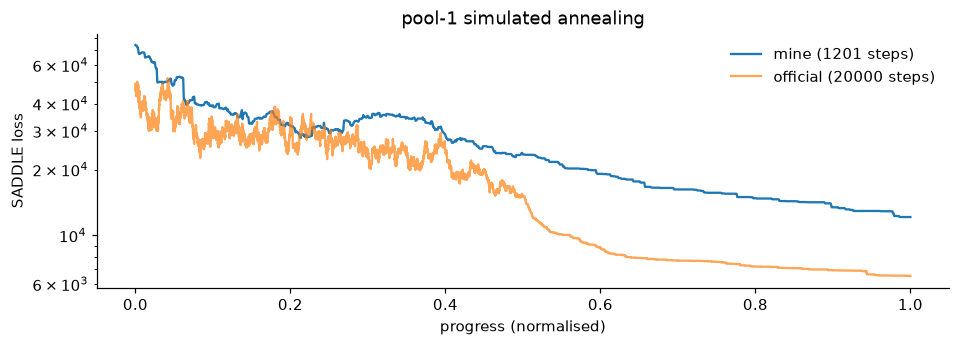

final loss: mine 12142   official 6524   random-start 74082


In [18]:
from collections import defaultdict
from math import floor
def conc_map(seqs_by_plex):
    m = defaultdict(float)
    for seq_list in seqs_by_plex.values():
        for s in seq_list: m[s] += 1.0/len(seq_list)
    return list(m.keys()), list(m.values())

def saddle(all_plex, tube, time_per_step, num_steps=10, seed=SEED):
    rnd = np.random.RandomState(seed)
    ids = [k for k, v in all_plex.items() if v['tube'] == tube]
    pairs = {k: [(f, r) for _, f in all_plex[k]['fP_candidate'].iterrows() for _, r in all_plex[k]['rP_candidate'].iterrows()] for k in ids}
    idx = {k: rnd.randint(len(pairs[k])) for k in ids}
    def loss(idx):
        indiv = sum(pairs[k][idx[k]][0]['badness'] + pairs[k][idx[k]][1]['badness'] for k in ids)
        fs, fc = conc_map({k: pairs[k][idx[k]][0]['seq'] for k in ids}); rs, rc = conc_map({k: pairs[k][idx[k]][1]['seq'] for k in ids})
        return indiv + design.PrimerSetBadnessFast(fs, rs, [], fc, rc)[0]
    cur = loss(idx); T0 = 1000 + 10*max(len(ids)-100, 0); T = T0; curve = [cur]
    for step in range(2*num_steps):
        for _ in range(time_per_step):
            k = ids[rnd.randint(len(ids))]
            if len(pairs[k]) == 1: continue
            new = dict(idx); new[k] = rnd.randint(len(pairs[k])); nl = loss(new)
            if nl < cur or (T > 0 and rnd.rand() < 2**((cur-nl)/T)): idx, cur = new, nl
            curve.append(cur)
        T = max(0, T - T0/num_steps)
    return idx, pairs, curve
TIME_PER_STEP = 60 if FAST else 1000
t = time.time(); idx1, pairs1, curve1 = saddle(all_plex, 1, TIME_PER_STEP); print(f'{len(curve1)} steps in {time.time()-t:.0f}s ({(time.time()-t)/len(curve1)*1000:.0f} ms/step)')
off_lc = d_off['learning_curve'][0]
fig, ax = plt.subplots(figsize=(10, 3)); ax.plot(np.linspace(0, 1, len(curve1)), curve1, label=f'mine ({len(curve1)} steps)'); ax.plot(np.linspace(0, 1, len(off_lc)), off_lc, label=f'official ({len(off_lc)} steps)', alpha=.7)
ax.set(yscale='log', xlabel='progress (normalised)', ylabel='SADDLE loss', title='pool-1 simulated annealing'); ax.legend(frameon=False); plt.savefig(FIG/'saddle_curve.png', bbox_inches='tight'); plt.show()
print('final loss: mine %.0f   official %.0f   random-start %.0f' % (curve1[-1], off_lc[-1], curve1[0]))

即使步数只有官方的 ~6%，也能把 Loss 压到起点的约 1/6；官方 20000 步更低（见上方最终 loss 对比）。**官方最终每个扩增子选用的引物对以 `olvd` 为准**，下一步用它做输出。（SA 受随机种子影响。官方在 `np.random.seed(10)`+`random.seed(10)` 下依次对 pool-1、pool-2 消耗同一随机流，所以上面这个精简重写只复现**曲线形态**；而直接运行仓库的 `get_primer → optimize → to_df`（官方 PDR、seed=10、单线程、约 15 分钟）我已验证得到的 **fP、rP 与官方 `olivar-design.csv` 100% 相同，两个 pool 的最终 SADDLE loss 分别为 6524.20 和 7147.60，与官方学习曲线末值逐位相等**。）

## 9. 输出：`to_df`、坐标与 BED

`to_df` 把每个扩增子的选定引物换算成 1-based 坐标：

```
start        = fp_stop  − dist_fP − len_fP + 1          # 扩增子起点
insert_start = start + len_fP
insert_end   = rp_start + dist_rP − 1
end          = insert_end + len_rP
```
并输出 ARTIC/PrimalScheme 的 BED（0-based，fP 为 `+`，rP 为 `-`，`_LEFT_1/_RIGHT_1`）。degenerate 模式下若一个引物含多个变体序列，会逐位合并为 IUPAC 简并碱基。

In [19]:
df_new, art_new = th.to_df(d_off['all_plex_info'], cfg)
df_off = pd.read_csv(ROOT/'example_output'/'olivar-design.csv')
print('to_df reproduces official olivar-design.csv:', df_new[df_off.columns].equals(df_off))
print(df_new[['amplicon_id', 'pool', 'fP', 'rP', 'start', 'end']].head(4).to_string(index=False))
df_new['amp_len'] = df_new['end'] - df_new['start'] + 1
print('amplicon length: mean %.0f, min %d, max %d' % (df_new.amp_len.mean(), df_new.amp_len.min(), df_new.amp_len.max()))
# tiling sanity: same-pool amplicons must not overlap, adjacent amplicons must overlap
ov = [(df_new.loc[i, 'end'] - df_new.loc[i+1, 'start'] + 1) for i in range(len(df_new)-1)]
same_pool_gap = [(g['start'].values[1:] - g['end'].values[:-1]).min() for _, g in df_new.groupby('pool')]
print('min gap between consecutive same-pool amplicons:', same_pool_gap, '(>0 means no overlap within pool);  adjacent-amplicon overlap: mean %.0f nt' % np.mean(ov))
print(open(ROOT/'example_output'/'olivar-design.primer.bed').read().splitlines()[:2])

to_df reproduces official olivar-design.csv: True
     amplicon_id  pool                          fP                    rP  start  end
EPI_ISL_402124_1     1          cggctgcatgcttagtgc   gacctcctccacggagtct    100  379
EPI_ISL_402124_2     2       caacgagaaaacacacgtcca accgtactgaatgccttcgag    289  559
EPI_ISL_402124_3     1      gttcatcaaacgttcggatgct  acgcatgagttcacgggtaa    472  790
EPI_ISL_402124_4     2 aggttcttcttcgtaagaacggtaata   ccagcacgtgctagaaggt    624  891
amplicon length: mean 327, min 231, max 410
min gap between consecutive same-pool amplicons: [8, 10] (>0 means no overlap within pool);  adjacent-amplicon overlap: mean 125 nt
['EPI_ISL_402124\t99\t117\tEPI_ISL_402124_1_LEFT_1\t1\t+\tCGGCTGCATGCTTAGTGC', 'EPI_ISL_402124\t288\t309\tEPI_ISL_402124_2_LEFT_1\t2\t+\tCAACGAGAAAACACACGTCCA']


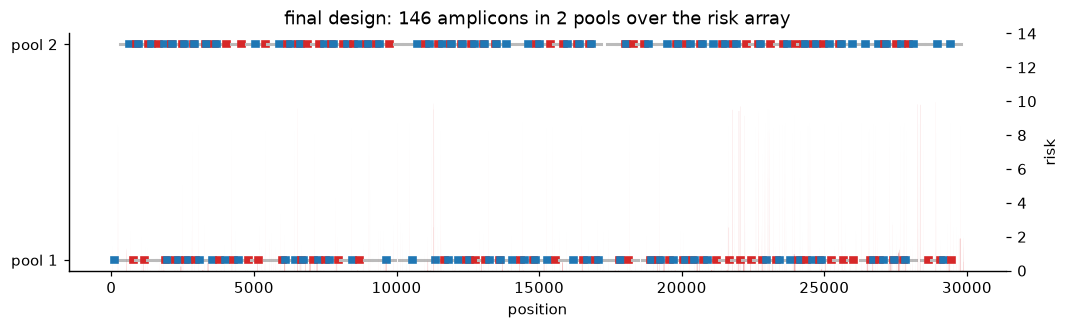

In [20]:
fig, ax = plt.subplots(figsize=(11, 2.8))
for _, r in df_new.iterrows():
    y = 0 if r.pool == 1 else 1
    ax.plot([r.start, r.end], [y, y], c='#bbb', lw=2); ax.plot([r.start, r.insert_start-1], [y, y], c='#1f77b4', lw=5); ax.plot([r.insert_end+1, r.end], [y, y], c='#d62728', lw=5)
ax2 = ax.twinx(); ax2.fill_between(np.arange(1, n+1), risk, color='#d62728', alpha=.35, lw=0); ax2.set_ylim(0, 14); ax2.set_ylabel('risk')
ax.set(yticks=[0, 1], yticklabels=['pool 1', 'pool 2'], xlabel='position', title='final design: 146 amplicons in 2 pools over the risk array'); plt.savefig(FIG/'final_design.png', bbox_inches='tight'); plt.show()

## 10. 验证：specificity 与 sensitivity

### 10.1 `specificity`（无 BLAST 部分）：每条引物的 GC、复杂度、dG、自身比对、二聚体分数

`main.specificity` 里没有 BLAST 库时只输出这张表；有 BLAST 库时再用 `precise` 模式（Primer-BLAST 参数）预测非特异扩增子：3' 端不能有悬挂、3' 最后 5nt 至多 1 错配、总错配 ≤4，同一条染色体上方向正确且间距 < `max_amp_len` 的两条命中即报告为一个非特异扩增子。

In [21]:
df_pool = df_off[df_off.pool == 1]
names, seqs = [], []
for _, r in df_pool.iterrows():
    seqs += [r.fP, r.rP]; names += [f'{r.amplicon_id}_fP', f'{r.amplicon_id}_rP']
_, bad = design.PrimerSetBadnessFast(seqs); bad = bad[0]
gen = design.primer_generator(temperature=60, salinity=0.18)
val = pd.DataFrame({'name': names, 'seq': seqs, 'length': [len(s) for s in seqs], '%GC': average_scores(seqs, basic.get_GC), 'complexity': average_scores(seqs, basic.get_complexity),
                    'dG (60C)': average_scores(seqs, lambda p: gen.dG_init + gen.StacksDG(p)), 'self_align': average_scores(seqs, design.WAlignScore), 'dimer_score': bad})
val_off = pd.read_csv(ROOT/'example_output'/'olivar-val_pool-1.csv')
print('reproduces official olivar-val_pool-1.csv:', {c: bool(np.allclose(val[c], val_off[c])) for c in ['%GC', 'complexity', 'dG (60C)', 'self_align', 'dimer_score']})
val.describe().loc[['mean', 'min', 'max'], ['length', '%GC', 'dG (60C)', 'dimer_score']].round(2)

reproduces official olivar-val_pool-1.csv: {'%GC': True, 'complexity': True, 'dG (60C)': True, 'self_align': True, 'dimer_score': True}


,length,%GC,dG (60C),dimer_score
mean,24.73,0.43,-12.14,43.05
min,16.00,0.24,-13.19,0.00
max,34.00,0.75,-11.81,269.87


### 10.2 `sensitivity` 与 degenerate（简并）模式：用 H1N1-HA 多序列比对

示例 `H1N1-HA.fasta` 有 4227 条 HA 序列（长度 232–1781，含简并碱基）。取 200 条完整长度、纯 ACGT 的序列，用 MAFFT 比对（耗时数秒），然后：

1. `MSA` → 投票得到**共识序列**；
2. `variant_call` → 每个位置相对共识的变异频率（`build` 里 `--min-var 0.01` 以上的写入 `_var.csv`）；
3. 对一条引物 `attach_primer`：局部比对到共识 → 取对应 MSA 列 → **sensitivity = 完全匹配该引物（含简并展开）的序列比例**。

MAFFT: 6.5s


MSA 200 x 1780 ; consensus length 1701
positions with variation freq >= 1%: 253 of 1701


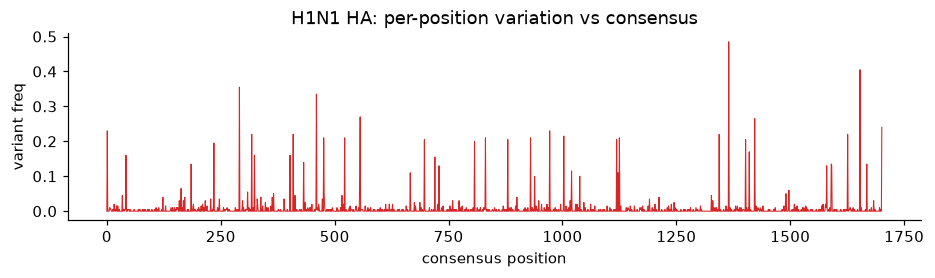

In [22]:
import random, msa_tools as mt
recs = [r for r in SeqIO.parse(ROOT/'example_input'/'H1N1-HA.fasta', 'fasta') if len(r.seq) >= 1700 and set(str(r.seq).upper()) <= set('ACGT')]
random.seed(0); sub = random.sample(recs, 200); SeqIO.write(sub, WORK/'h1n1_200.fasta', 'fasta')
t = time.time(); aln = subprocess.run(['mafft', '--auto', '--thread', '2', str(WORK/'h1n1_200.fasta')], capture_output=True, text=True).stdout
(WORK/'h1n1_aln.fasta').write_text(aln); print(f'MAFFT: {time.time()-t:.1f}s')
msa = mt.MSA(str(WORK/'h1n1_aln.fasta')); print('MSA', msa.row, 'x', msa.col, '; consensus length', len(msa.consensus))
vd = msa.variant_call(); freq = np.zeros(len(msa.consensus)+1)
for p, f in vd.items(): freq[p] = f
print('positions with variation freq >= 1%:', sum(f >= .01 for f in vd.values()), 'of', len(msa.consensus))
fig, ax = plt.subplots(figsize=(10, 2.2)); ax.plot(freq, lw=.7, color='#d62728'); ax.set(xlabel='consensus position', ylabel='variant freq', title='H1N1 HA: per-position variation vs consensus'); plt.savefig(FIG/'h1n1_variation.png', bbox_inches='tight'); plt.show()

In [23]:
# pick the most conserved and a most variable 22-nt window, make a primer from each and attach
cons = msa.consensus; win = 22
score = np.array([freq[i+1:i+1+win].sum() for i in range(len(cons)-win)])
good, bad_ = int(np.argmin(score)), int(np.argmax(score))
for label, i in [('conserved', good), ('variable', bad_)]:
    p = msa.attach_primer(cons[i:i+win], 60.0, 0.18, name=f'{label}@{i}')
    print(p.printed)

conserved@1303
GC: 40.91%
dG (60.0°C): -11.30 kcal/mol
primer/consensus:
   0 TTTGGACTTACAATGCCGAACT 22
     ||||||||||||||||||||||
1303 TTTGGACTTACAATGCCGAACT 1325
sensitivity: 99.50% (199/200)

variable@1343
GC: 36.36%
dG (60.0°C): -9.20 kcal/mol
primer/consensus:
   0 CGAAAGAACTTTGGACTATCAT 22
     ||||||||||||||||||||||
1343 CGAAAGAACTTTGGACTATCAT 1365
sensitivity: 35.00% (70/200)



**degenerate 模式**（`--deg`）的思路：共识序列不再取“最多数碱基”，而是按频率从高到低累积碱基直到累计 ≥70%，用 IUPAC 码表示（如 `R=A/G`）；风险里加入 `sensi_arr`（窗口 100−敏感性）和 `combi_arr`（简并展开后序列数−1），引物以展开后各变体的平均 ΔG/GC/复杂度打分，SADDLE 里每个变体按 `1/n` 浓度计入二聚体。下面看一个 28nt 窗口在 deg 与非 deg 共识下的灵敏度：

In [24]:
msa_d = mt.MSA(str(WORK/'h1n1_aln.fasta')); msa_d._get_consensus(deg=True, show_progress=False)
print('non-degenerate consensus window:', msa.consensus[good:good+28]); print('degenerate     consensus window:', msa_d.consensus[good:good+28])
i = bad_
for name, m in [('plain', msa), ('deg', msa_d)]:
    w = m.consensus[i:i+28]
    s = mt.get_sensitivity(w, i, i+28, str(WORK/'h1n1_aln.fasta'), deg=(name == 'deg'))
    print(f'{name:5s} variable window {i}: {w}  sensitivity = {s:.1f}%  combinations = {basic.get_combinations(w)}')

non-degenerate consensus window: TTTGGACTTACAATGCCGAACTGCTGGT
degenerate     consensus window: TTTGGACTTACAATGCCGAACTGCTGGT


plain variable window 1343: CGAAAGAACTTTGGACTATCATGATTCA  sensitivity = 33.5%  combinations = 1


deg   variable window 1343: CGAAAGAACTTTGGACTATCAYGATTCA  sensitivity = 75.0%  combinations = 2


## 11. 附录：实测发现的问题与改进原型

下面每一项都有可执行的证据，对应 `docs/Olivar_walkthrough.html` 第 6 节的建议。

### 11.1 SADDLE 每一步的耗时去哪了？

In [25]:
np.random.seed(1); import random as _r; _r.seed(1)
from copy import deepcopy
ids = [k for k, v in all_plex.items() if v['tube'] == 1]
tt = {}
fps = {k: all_plex[k]['fP_candidate'].iloc[0]['seq'] for k in ids}; rps = {k: all_plex[k]['rP_candidate'].iloc[0]['seq'] for k in ids}
t = time.time(); [deepcopy(fps) for _ in range(200)]; tt['deepcopy of 2 dicts'] = (time.time()-t)/200*2
t = time.time(); [conc_map(fps) for _ in range(200)]; tt['get_concentration x2'] = (time.time()-t)/200*2
fs, fc = conc_map(fps); rs, rc = conc_map(rps)
t = time.time(); [design.PrimerSetBadnessFast(fs, rs, [], fc, rc) for _ in range(50)]; tt['PrimerSetBadnessFast'] = (time.time()-t)/50
tot = sum(tt.values()); print({k: f'{v*1000:.2f} ms ({100*v/tot:.0f}%)' for k, v in tt.items()}, f'| total {tot*1000:.1f} ms/step')
print('=> 99% of the time is the full re-computation of the k-mer hash tables and the lookups for ALL 146 primers, although one step changes only 2 primers.')

{'deepcopy of 2 dicts': '0.25 ms (1%)', 'get_concentration x2': '0.05 ms (0%)', 'PrimerSetBadnessFast': '20.26 ms (99%)'} | total 20.6 ms/step
=> 99% of the time is the full re-computation of the k-mer hash tables and the lookups for ALL 146 primers, although one step changes only 2 primers.


### 11.2 `hits_arr`：官方人类库的 BLAST 命中几乎处处非零

positions with hits>0: 99.91%;   max 6081;   median 28.5;   99th pct 290
after /max normalisation: median 0.0047, 99th pct 0.048, fraction > 0.1: 0.469%


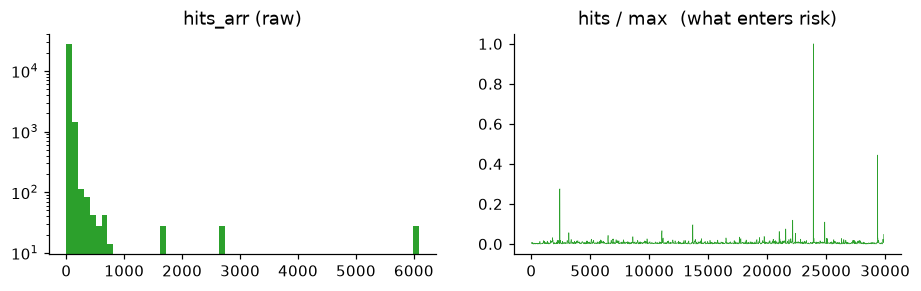

In [26]:
h = off['hits_arr']
print('positions with hits>0: %.2f%%;   max %.0f;   median %.1f;   99th pct %.0f' % (100*(h > 0).mean(), h.max(), np.median(h), np.percentile(h, 99)))
hn = h / h.max(); print('after /max normalisation: median %.4f, 99th pct %.3f, fraction > 0.1: %.3f%%' % (np.median(hn), np.percentile(hn, 99), 100*(hn > .1).mean()))
fig, ax = plt.subplots(1, 2, figsize=(10, 2.6)); ax[0].hist(h, 60, color='#2ca02c'); ax[0].set_yscale('log'); ax[0].set_title('hits_arr (raw)'); ax[1].plot(hn, lw=.4, color='#2ca02c'); ax[1].set_title('hits / max  (what enters risk)'); plt.show()

rough 模式的命中条数既不区分 3' 端能否延伸，也不区分错配数（§4 的合成库实验已显示信噪比≈1）。再加上 `/max` 归一化：只要库里有一个超重复区（max=6081），其余 99% 的位置 `ns` 项 <0.05，实际进入风险数组的只剩极少数极端位置（>0.1 的仅 0.47%），其余位置的差异被噪声和归一化双重抹平，风险排序基本由变异项主导。

### 11.3 `get_sensitivity`（degenerate 模式）每个窗口都重新读入整个 MSA 并重算共识

In [27]:
t = time.time(); [mt.get_sensitivity(msa.consensus[100:128], 100, 128, str(WORK/'h1n1_aln.fasta'), False) for _ in range(3)]; per = (time.time()-t)/3
print(f'one call: {per:.2f}s with a 200-sequence MSA. For a 30 kb genome there are ~2100 windows -> {per*2100/60:.0f} min of pure re-loading; for the 4227-sequence H1N1 MSA or a 10^4–10^5-sequence SARS-CoV-2 MSA it grows linearly with MSA size and is repeated in every worker process.')

one call: 0.60s with a 200-sequence MSA. For a 30 kb genome there are ~2100 windows -> 21 min of pure re-loading; for the 4227-sequence H1N1 MSA or a 10^4–10^5-sequence SARS-CoV-2 MSA it grows linearly with MSA size and is repeated in every worker process.


### 11.4 `build_helper` 里 BLAST 命中的索引错位（degenerate 模式）

`BLAST_batch_short(..., mode='rough')` 用 `int(query_name.split('_')[1])` 作为结果下标，而 `build_helper` 传入的名字是 `query_{原窗口序号 i}_{变体序号 j}`，下标却是**展开后列表**的位置。只要某个窗口展开出 >1 个变体，后面所有窗口的命中都会被写到错误位置；同一窗口的多个变体还会互相覆盖。演示（用 §4 的合成库）：

In [28]:
planted = refU[20000:20028]                    # 20 copies in DB
w_amb = planted[:10] + 'R' + planted[11:]      # one degenerate base -> 2 variants
words_demo = [refU[5000:5028], w_amb, planted, refU[7000:7028]]      # window 1 expands to 2 variants, so window 2 is shifted by one
exp, names, vmap = [], [], []
for i, w in enumerate(words_demo):
    vs = expand_degenerate_sequence(w.lower().upper()); exp += vs; names += [f'query_{i}_{j}' for j in range(len(vs))]; vmap += [i]*len(vs)
hits, _ = BLAST_batch_short(exp, db=str(WORK/'bgdb'), n_cpu=1, seq_names=names, mode='rough')
direct, _ = BLAST_batch_short(exp, db=str(WORK/'bgdb'), n_cpu=1, seq_names=[f'query_{k}' for k in range(len(exp))], mode='rough')
merged = [0]*len(words_demo)
for k, hcount in enumerate(hits): merged[vmap[k]] += hcount
merged_true = [0]*len(words_demo)
for k, hcount in enumerate(direct): merged_true[vmap[k]] += hcount
print('expanded variants:', len(exp), '| per-window hits as computed by build_helper logic :', merged)
print('                                    | per-window hits with correct indexing           :', merged_true)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|>>>>>>>>>>| 5/5 [00:00<00:00, 107.82it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

100%|>>>>>>>>>>| 5/5 [00:00<00:00, 122.55it/s]

expanded variants: 5 | per-window hits as computed by build_helper logic : [10, 46, 4, 0]
                                    | per-window hits with correct indexing           : [10, 46, 23, 4]


### 11.5 版本差异与可复现性

`comp_arr` 的归一化改变（§3.2）+ `.olvr/.olvd` 用 `pickle` 存储（含 Biopython 对象，换版本可能读不出，且有安全风险）+ BLAST 临时文件写进**包安装目录**（`BLAST_query.fasta` / `BLAST_result.*`，多进程/只读安装/并行运行时会互相覆盖）——这三点都影响“同样输入、同样种子得到同样结果”。

## 小结

| 阶段 | 复现结果 |
|---|---|
| build：`gc_arr`、`var_arr`、窗口、设计区间 | 与官方 `.olvr` **完全一致**；`comp_arr` 差一个 `n_cycle` 因子 |
| risk 数组 | 官方 `hits_arr` + 上述公式 → 与官方 `risk_arr` **完全一致** |
| 非特异性 | 合成库实验：rough 计数信噪比≈1，precise 过滤后信号干净（§4） |
| PDR 搜索 | `cumsum` 重写与原函数**逐位一致**，单核 ~30× 加速；完整 35584 重启得到与官方相同的 146 个扩增子 |
| 引物候选 | 每个 PDR 的候选数与官方一致 |
| SADDLE | 精简重写的 Loss 曲线形态与官方一致；原函数 `optimize`（seed=10）全量运行得到的引物与官方 CSV 100% 相同 |
| specificity 基础指标 | 与官方 `olivar-val_pool-1.csv` 一致 |